In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# =========================================================
# 2. IMPORT THƯ VIỆN
# =========================================================
import os
import math
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

try:
  from xgboost import XGBRegressor
except ImportError:
  subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])
  from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, StratifiedGroupKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, f_classif

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")


# 3. Các hàm dùng chung


In [ ]:

# =========================================================
# 3.1. HÀM ĐỌC DỮ LIỆU
# =========================================================
def read_dataset(file_path):
    """
    Đọc dữ liệu từ file CSV hoặc Excel.
    """
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path)
    elif ext in [".xlsx", ".xls"]:
        df = pd.read_excel(file_path)
    else:
        raise ValueError("Chỉ hỗ trợ file .csv, .xlsx, .xls")

    # Chuẩn hóa tên cột để tránh lỗi do khoảng trắng
    df.columns = [str(col).strip() for col in df.columns]
    return df

In [ ]:
# =========================================================
# 3.3. HÀM HIỂN THỊ THÔNG TIN TỔNG QUAN
# =========================================================
def show_overview(df, target_column):
    print("Kích thước dữ liệu:", df.shape)
    print("\n5 dòng đầu của dữ liệu:")
    display(df.head())

    print("\nThông tin kiểu dữ liệu:")
    display(df.info())

    print("\nThống kê mô tả:")
    display(df.describe(include="all").T)

    print("\nSố lượng giá trị thiếu trên từng cột:")
    display(df.isnull().sum().sort_values(ascending=False))

    if target_column in df.columns:
        print(f"\nPhân bố của biến mục tiêu: {target_column}")
        display(df[target_column].value_counts(dropna=False).head(20))

In [ ]:

# =========================================================
# 3.4. HÀM VẼ BIỂU ĐỒ PHÂN PHỐI CHO BIẾN SỐ
# =========================================================
def plot_numeric_distributions(df, max_cols=12):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

    if len(numeric_cols) == 0:
        print("Không có cột số để vẽ biểu đồ phân phối.")
        return

    cols_to_plot = numeric_cols[:max_cols]
    n = len(cols_to_plot)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_to_plot):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f"Phân phối của {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:

# =========================================================
# 3.5. HÀM VẼ BOXPLOT ĐỂ QUAN SÁT OUTLIER
# =========================================================
def plot_boxplots(df, exclude_columns=None, max_cols=12):
    if exclude_columns is None:
        exclude_columns = []

    numeric_cols = [
        col for col in df.select_dtypes(include=np.number).columns
        if col not in exclude_columns
    ]

    if len(numeric_cols) == 0:
        print("Không có cột số để vẽ boxplot.")
        return

    cols_to_plot = numeric_cols[:max_cols]
    n = len(cols_to_plot)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4*nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_to_plot):
        sns.boxplot(x=df[col], ax=axes[i])
        axes[i].set_title(f"Boxplot của {col}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:

# =========================================================
# 3.6. HÀM PHÂN TÍCH TỶ LỆ OUTLIER THEO IQR
# =========================================================
def outlier_report_iqr(df, exclude_columns=None):
    if exclude_columns is None:
        exclude_columns = []

    numeric_cols = [
        col for col in df.select_dtypes(include=np.number).columns
        if col not in exclude_columns
    ]

    report = []

    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        mask = (df[col] < lower) | (df[col] > upper)
        outliers = mask.sum()
        ratio = outliers / len(df) * 100

        report.append({
            "Thuộc tính": col,
            "Số lượng outlier": int(outliers),
            "Tỷ lệ (%)": round(ratio, 2)
        })

    report_df = pd.DataFrame(report).sort_values(by="Tỷ lệ (%)", ascending=False)
    return report_df

In [ ]:

# =========================================================
# 3.7. HÀM XỬ LÝ OUTLIER BẰNG IQR
# =========================================================
def handle_outliers_iqr(df, exclude_columns=None, method="clip"):
    """
    method = 'clip'  : cắt giá trị vượt ngưỡng về ngưỡng dưới / ngưỡng trên
    method = 'remove': loại bỏ các dòng chứa outlier
    """
    if exclude_columns is None:
        exclude_columns = []

    df = df.copy()
    numeric_cols = [
        col for col in df.select_dtypes(include=np.number).columns
        if col not in exclude_columns
    ]

    if method == "clip":
        for col in numeric_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            df[col] = df[col].clip(lower=lower, upper=upper)

    elif method == "remove":
        mask_all = pd.Series([True] * len(df), index=df.index)
        for col in numeric_cols:
            q1 = df[col].quantile(0.25)
            q3 = df[col].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            mask_col = (df[col] >= lower) & (df[col] <= upper)
            mask_all &= mask_col
        df = df[mask_all].copy()

    else:
        raise ValueError("method chỉ nhận 'clip' hoặc 'remove'")

    return df

In [ ]:

# =========================================================
# 3.8. HÀM VẼ MA TRẬN TƯƠNG QUAN
# =========================================================
def plot_correlation_matrix(df, target_column=None):
    numeric_df = df.select_dtypes(include=np.number).copy()

    if target_column is not None and target_column in df.columns:
        if target_column not in numeric_df.columns:
            # Nếu target không phải kiểu số thì không đưa vào ma trận tương quan
            pass

    if numeric_df.shape[1] < 2:
        print("Không đủ cột số để vẽ ma trận tương quan.")
        return

    corr = numeric_df.corr()

    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Ma trận tương quan")
    plt.show()

In [ ]:

# =========================================================
# 3.9. HÀM TẠO BỘ TIỀN XỬ LÝ (MÃ HÓA + CHUẨN HÓA)
# =========================================================
def build_preprocessor(X):
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
          drop="first",
          handle_unknown="ignore"
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )

    return preprocessor, numeric_features, categorical_features

In [ ]:
# =========================================================
# 3.10. HÀM XEM TRƯỚC KẾT QUẢ MÃ HÓA VÀ CHUẨN HÓA
# =========================================================
def preview_preprocessing(X_train, X_test, n_rows=5):
    """
    Hàm này giúp sinh viên nhìn rõ pipeline đã:
    - Điền khuyết dữ liệu
    - Mã hóa biến phân loại bằng OneHotEncoder
    - Chuẩn hóa biến số bằng StandardScaler

    Lưu ý:
    - Chỉ fit trên X_train và transform trên X_test để tránh rò rỉ dữ liệu.
    - Hàm này dùng để quan sát kết quả tiền xử lý.
    - Khi huấn luyện mô hình, các bước này vẫn được thực hiện lại bên trong Pipeline sklearn.
    """
    preprocessor, numeric_features, categorical_features = build_preprocessor(X_train)

    X_train_processed = preprocessor.fit_transform(X_train)
    X_test_processed = preprocessor.transform(X_test)

    feature_names = preprocessor.get_feature_names_out()

    print("Các cột số sẽ được chuẩn hóa:")
    print(numeric_features if len(numeric_features) > 0 else "Không có")

    print("\nCác cột phân loại sẽ được mã hóa One-Hot:")
    print(categorical_features if len(categorical_features) > 0 else "Không có")

    print("\nKích thước dữ liệu trước tiền xử lý:")
    print("X_train gốc:", X_train.shape)
    print("X_test gốc :", X_test.shape)

    print("\nKích thước dữ liệu sau tiền xử lý:")
    print("X_train sau mã hóa + chuẩn hóa:", X_train_processed.shape)
    print("X_test sau mã hóa + chuẩn hóa :", X_test_processed.shape)

    sample = X_train_processed[:n_rows]
    if hasattr(sample, "toarray"):
        sample = sample.toarray()

    preview_df = pd.DataFrame(sample, columns=feature_names)
    print(f"\nXem trước {n_rows} dòng đầu sau khi mã hóa và chuẩn hóa:")
    display(preview_df)

    return preprocessor, feature_names, X_train_processed, X_test_processed

In [ ]:

# =========================================================
# 3.11. HÀM TÌM ĐẶC TRƯNG ĐƯỢC CHỌN BỞI SelectKBest
# =========================================================
def get_selected_feature_names(X_train, y_train, problem_type="regression", k="auto"):
    preprocessor, _, _ = build_preprocessor(X_train)
    X_train_processed = preprocessor.fit_transform(X_train)

    feature_names = preprocessor.get_feature_names_out()

    if k == "auto":
        k_value = min(10, X_train_processed.shape[1])
    else:
        k_value = min(int(k), X_train_processed.shape[1])

    if problem_type == "regression":
        selector = SelectKBest(score_func=f_regression, k=k_value)
    else:
        selector = SelectKBest(score_func=f_classif, k=k_value)

    selector.fit(X_train_processed, y_train)

    selected_mask = selector.get_support()
    selected_names = np.array(feature_names)[selected_mask]

    selected_df = pd.DataFrame({
      "Đặc trưng": feature_names,
      "Score": selector.scores_,
      "P-value": selector.pvalues_,
      "Được chọn": selector.get_support()
    }).sort_values("Score", ascending=False)

    return selected_names, selected_df

In [ ]:

# =========================================================
# 3.12. HÀM TẠO PIPELINE CHUNG CHO MỖI MÔ HÌNH
# =========================================================
def build_model_pipeline(X_train, model, problem_type="regression", k="auto"):
    preprocessor, _, _ = build_preprocessor(X_train)

    # Tính số đặc trưng sau tiền xử lý để chọn k phù hợp
    X_train_processed = preprocessor.fit_transform(X_train)
    if k == "auto":
        k_value = min(10, X_train_processed.shape[1])
    else:
        k_value = min(int(k), X_train_processed.shape[1])

    if problem_type == "regression":
        selector = SelectKBest(score_func=f_regression, k=k_value)
    else:
        selector = SelectKBest(score_func=f_classif, k=k_value)

    pipe = Pipeline(steps=[
        ("preprocessor", build_preprocessor(X_train)[0]),
        ("selector", selector),
        ("model", model)
    ])

    return pipe

In [ ]:
def missing_data_percent(df_reg):
  missing = df_reg.isnull().sum()

  missing_percent = (
      missing / len(df_reg) * 100
  )

  pd.DataFrame({
      "Missing":missing,
      "Percent": missing_percent
  }).sort_values("Percent", ascending=False)
  return missing_percent

# 4. PIPELINE 1 - Bài toán dự báo / hồi quy

Giới thiệu về dataset
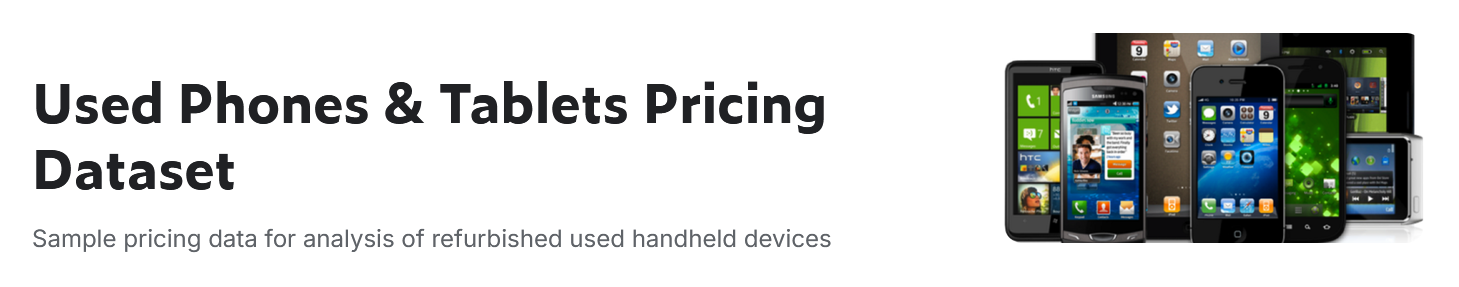

- column(Feature) = 15
- row = 3454
- target = normalized_used_price
- Quy trình xử lý dữ liệu mất mát: Ưu tiên so sánh các dữ liệu có thông số giống với dữ liệu thiếu để điền vào hoặc xem mối tương quan giữa các dữ liệu để điền. Nếu không có dữ liệu tương tự nhưng có hầu hết các feature của một index thì tra cứu từ nguồn bên ngoài (đối với các feature mất mát ít), cuối cùng nếu không tra cứu được thì nếu dữ liệu ít hơn 10% sẽ xóa đi còn nhiều hơn thì sẽ dùng median để điền vào.

In [ ]:

# =========================================================
# 4.1. CẤU HÌNH CHO BÀI TOÁN HỒI QUY
# Sinh viên chỉ cần sửa 3 biến dưới đây
# =========================================================
FILE_PATH_REG = "/content/drive/MyDrive/DATASET/used_device_data.csv"
TARGET_COLUMN_REG = "normalized_used_price"
TEST_SIZE_REG = 0.2
RANDOM_STATE_REG = 42
K_BEST_REG = "auto"


In [ ]:
# =========================================================
# 4.2. ĐỌC DỮ LIỆU VÀ XỬ LÝ CỘT NGÀY GIỜ
# =========================================================
df_reg = read_dataset(FILE_PATH_REG)
print("Đọc dữ liệu thành công.")

Đọc dữ liệu thành công.


In [ ]:
df_reg.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [ ]:
df_reg.shape

(3454, 15)

In [ ]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [ ]:
df_reg.describe().T

,count,mean,std,min,25%,50%,75%,max
screen_size,3454.0,13.713115,3.805280,5.080000,12.700000,12.830000,15.340000,30.710000
main_camera_mp,3275.0,9.460208,4.815461,0.080000,5.000000,8.000000,13.000000,48.000000
selfie_camera_mp,3452.0,6.554229,6.970372,0.000000,2.000000,5.000000,8.000000,32.000000
int_memory,3450.0,54.573099,84.972371,0.010000,16.000000,32.000000,64.000000,1024.000000
ram,3450.0,4.036122,1.365105,0.020000,4.000000,4.000000,4.000000,12.000000
battery,3448.0,3133.402697,1299.682844,500.000000,2100.000000,3000.000000,4000.000000,9720.000000
weight,3447.0,182.751871,88.413228,69.000000,142.000000,160.000000,185.000000,855.000000
release_year,3454.0,2015.965258,2.298455,2013.000000,2014.000000,2015.500000,2018.000000,2020.000000
days_used,3454.0,674.869716,248.580166,91.000000,533.500000,690.500000,868.750000,1094.000000
normalized_used_price,3454.0,4.364712,0.588914,1.536867,4.033931,4.405133,4.755700,6.619433


In [ ]:
#Tính phần trăm dữ liệu bị mất mát
print(missing_data_percent(df_reg))

brand_name               0.000000
os                       0.000000
screen_size              0.000000
4g                       0.000000
5g                       0.000000
main_camera_mp           5.182397
selfie_camera_mp         0.057904
int_memory               0.115808
ram                      0.115808
battery                  0.173712
weight                   0.202664
release_year             0.000000
days_used                0.000000
normalized_used_price    0.000000
normalized_new_price     0.000000
dtype: float64


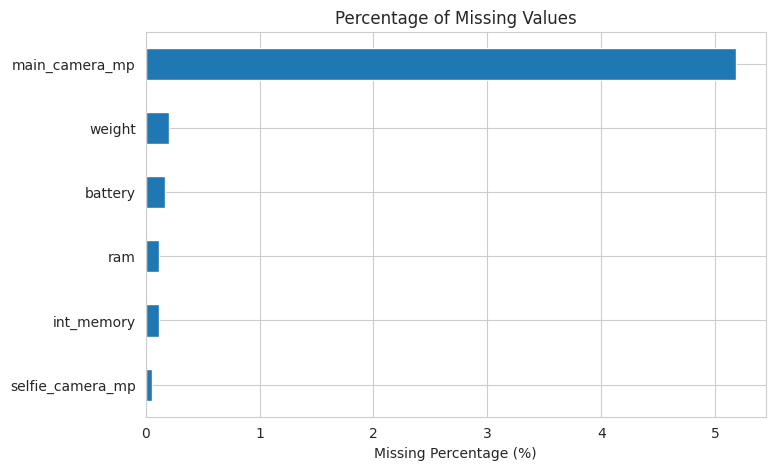

In [ ]:
missing_percent = df_reg.isnull().mean()*100

missing_percent = missing_percent[missing_percent>0]

missing_percent.sort_values().plot.barh(figsize=(8,5))

plt.xlabel("Missing Percentage (%)")
plt.title("Percentage of Missing Values")
plt.show()

# **Xử lí dữ liệu bị thiếu**
- bắt đầu từ các feature bị thiếu ít và độ tương quan với các feature khác không rõ

In [ ]:
df_reg[df_reg["battery"].isnull()]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1829,Meizu,Android,12.83,yes,no,13.0,5.0,16.00,4.00,NaN,145.0,2014,986,4.177919,4.863604
1831,Meizu,Android,12.83,yes,no,20.7,5.0,16.00,4.00,NaN,158.0,2014,1043,4.878855,5.990639
1832,Meizu,Android,13.61,yes,no,20.7,2.0,16.00,4.00,NaN,147.0,2014,1007,4.742320,5.826118
1962,Microsoft,Windows,25.55,no,no,5.0,3.5,32.00,4.00,NaN,675.9,2013,931,5.230574,5.802753
2058,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.02,NaN,81.0,2016,815,2.718660,3.374511
2059,Nokia,Others,5.18,no,no,0.3,0.0,0.06,NaN,NaN,82.6,2016,1023,2.765060,3.657905


**Trước tiên có 3 máy thuộc dòng Meizu bị thiếu battery nên sẽ tra cứu xem có các máy cùng dòng và cùng năm và có thông số pin hay không**

In [ ]:
df_reg[
    (df_reg["brand_name"] == "Meizu") &
    (df_reg["release_year"] == 2014) &
    (df_reg["weight"] == 145.0) &
    (df_reg["screen_size"] == 12.83)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1829,Meizu,Android,12.83,yes,no,13.0,5.0,16.0,4.0,NaN,145.0,2014,986,4.177919,4.863604


**Vì không có máy nào khác cùng năm cùng dòng có thông số dung lượng pin, và chỉ có 3 dòng nên thực hiện tra cứu dữ liệu bên ngoài để xem có thể điền vào được hay không**

In [ ]:
#Sau khi tra cứu thì tìm được 2 thông số pin của 2 máy là 1829 và 1832
df_reg.loc[1829, "battery"] = 3140
df_reg.loc[1832, "battery"] = 3100

**Còn một máy thuộc dòng Meizu, 2 máy Nokia và 1 Microsoft bị thiếu dữ liệu Battery**

In [ ]:
#Kiểm tra xem còn máy thuộc dòng Nokia có dữ liệu tương tự
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2016) &
    (df_reg["screen_size"] == 5.18) &
    (df_reg["weight"] == 82.6	)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2059,Nokia,Others,5.18,no,no,0.3,0.0,0.06,NaN,NaN,82.6,2016,1023,2.76506,3.657905


In [ ]:
#Kiểm tra xem còn máy thuộc dòng Nokia có dữ liệu tương tự
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2016) &
    (df_reg["screen_size"] == 5.18) &
    (df_reg["weight"] == 81.0)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2058,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.02,NaN,81.0,2016,815,2.71866,3.374511


In [ ]:
#Kiểm tra xem còn máy thuộc dòng Nokia có dữ liệu tương tự
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2016) &
    (df_reg["screen_size"] == 5.18) &
    (df_reg["main_camera_mp"] == 0.3)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2058,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.02,NaN,81.0,2016,815,2.71866,3.374511
2059,Nokia,Others,5.18,no,no,0.3,0.0,0.06,NaN,NaN,82.6,2016,1023,2.76506,3.657905


In [ ]:
#Theo quan sát thì 2 máy có lẽ cùng dòng nên sẽ điền ram cho index 2059 bằng thông số ram của index 2058 cho index 2059
df_reg.loc[2059, "ram"] = 0.02

In [ ]:
# Vì không còn máy nào khác có thông số battery mà cùng dòng và năm sx nên sẽ tra lứu dữ liệu bên ngoài để điền
df_reg.loc[2058, "battery"] = 1020
df_reg.loc[2059, "battery"] = 1020

**Vì còn 2 máy thuộc index 1831, 1962 không tìm thấy dữ liệu phù hợp để điền vào nên sẽ xóa 2 index này vì nếu dùng mean thì sẽ có khả năng sai lệch dữ liệu và hiện tại tổng dữ liệu có 3454 nên bỏ 2 thì chỉ khoảng 0.06% sẽ không ảnh hưởng đến mô hình**

In [ ]:
df_reg = df_reg.drop(index=[1831, 1962])

In [ ]:
df_reg.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,3
battery,0


**Xử lí tiếp feature selfie_camera_mp**

In [ ]:
row = df_reg[df_reg["selfie_camera_mp"].isna()]
row.T

,1080,1081
brand_name,Google,Google
os,Android,Android
screen_size,15.32,12.83
4g,yes,yes
5g,no,no
main_camera_mp,12.2,12.2
selfie_camera_mp,NaN,NaN
int_memory,64.0,64.0
ram,4.0,4.0
battery,3430.0,2915.0


**Theo quan sát thì 2 máy cùng năm sx nhưng index 1080 có lẽ là bảng cao cấp hơn 1081**

In [ ]:
#Kiểm tra xem có index nào thuộc cùng dòng và cùng thông số với 2 máy không
df_reg[
    (df_reg["brand_name"] == "Google") &
    (df_reg["release_year"] == 2018) &
    (df_reg["ram"] == 4) &
    (df_reg["main_camera_mp"] == 12.2)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1080,Google,Android,15.32,yes,no,12.2,NaN,64.0,4.0,3430.0,184.0,2018,475,5.573826,6.865974
1081,Google,Android,12.83,yes,no,12.2,NaN,64.0,4.0,2915.0,148.0,2018,424,4.464988,6.745083


In [ ]:
#Vì chỉ có 2 máy thuộc cùng năm sx cùng hãng và cùng thông số cam chính nên sẽ tra cứu từ bên ngoài và tìm được selfie camera của 2 máy là 8
df_reg.loc[1080, "selfie_camera_mp"] = 8
df_reg.loc[1081, "selfie_camera_mp"] = 8

In [ ]:
df_reg.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,0
int_memory,4
ram,3
battery,0


**Tiếp theo là xử lý đến ram**

In [ ]:
row = df_reg[df_reg["ram"].isnull()]
row.T

,114,335,2090
brand_name,Nokia,Nokia,Nokia
os,Others,Others,Others
screen_size,5.18,5.18,7.62
4g,no,no,no
5g,no,no,no
main_camera_mp,0.3,0.3,5.0
selfie_camera_mp,0.0,0.0,0.0
int_memory,0.06,0.1,0.06
ram,NaN,NaN,NaN
battery,1020.0,1200.0,1200.0


In [ ]:
#Kiểm tra các index có cùng thông số với index 144
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2020) &
    (df_reg["battery"] == 1020)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
113,Nokia,Others,5.18,no,no,0.3,0.0,0.10,0.03,1020.0,90.5,2020,272,2.910174,3.399863
114,Nokia,Others,5.18,no,no,0.3,0.0,0.06,NaN,1020.0,91.3,2020,288,2.729159,2.911263
332,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.03,1020.0,90.5,2020,322,2.519308,3.386422
333,Nokia,Others,5.18,no,no,0.3,0.0,0.10,0.03,1020.0,91.3,2020,148,2.564949,3.011606


In [ ]:
#Dự vào dữ liệu về ram của index 332 sẽ điền cho index 114
df_reg.loc[114, "ram"] =0.03

In [ ]:
#Kiểm tra các index có cùng thông số với index 335
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2020) &
    (df_reg["battery"] == 1200)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
116,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.02,1200.0,88.2,2020,266,3.370738,3.699077
335,Nokia,Others,5.18,no,no,0.3,0.0,0.10,NaN,1200.0,88.2,2020,327,3.062924,3.689129


In [ ]:
#Điền thông số ram từ index 116 cho index 335
df_reg.loc[335, "ram"] =0.02

In [ ]:
#Kiểm tra các index có cùng thông số với index 2090
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2013) &
    (df_reg["battery"] == 1200)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2089,Nokia,Windows,25.43,yes,no,6.70,2.0,32.00,4.00,1200.0,615.0,2013,1067,4.978319,5.882431
2090,Nokia,Others,7.62,no,no,5.00,0.0,0.06,NaN,1200.0,111.4,2013,1001,3.827771,4.605770
2091,Nokia,Others,7.62,no,no,5.00,0.0,0.10,0.03,1200.0,110.2,2013,987,3.881358,4.517322
2093,Nokia,Others,5.28,no,no,2.00,0.0,0.06,0.03,1200.0,101.3,2013,893,3.418382,4.092510
2094,Nokia,Others,5.28,no,no,2.00,0.0,0.06,0.03,1200.0,101.0,2013,782,3.292126,4.081766
2095,Nokia,Others,5.18,no,no,5.00,0.0,0.06,0.03,1200.0,101.1,2013,863,4.391977,4.943284
2102,Nokia,Others,7.62,no,no,3.15,0.0,0.06,0.02,1200.0,98.2,2013,668,3.532518,4.382527
2103,Nokia,Others,5.18,no,no,2.00,0.0,0.10,0.03,1200.0,97.3,2013,713,3.216072,3.935153


In [ ]:
df_reg.loc[2090, "ram"] =0.03

In [ ]:
df_reg.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,0
int_memory,4
ram,0
battery,0


**Tiếp theo là xử lý đến int_memory**

In [ ]:
row = df_reg[df_reg["int_memory"].isna()]
row.T

,117,2035,2064,2092
brand_name,Nokia,Nokia,Nokia,Nokia
os,Others,Others,Others,Others
screen_size,5.18,5.18,5.18,7.62
4g,yes,no,no,no
5g,no,no,no,no
main_camera_mp,0.3,5.0,0.3,5.0
selfie_camera_mp,0.0,0.0,0.0,0.0
int_memory,NaN,NaN,NaN,NaN
ram,0.02,0.03,0.02,0.02
battery,1200.0,1020.0,1100.0,1010.0


In [ ]:
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2015) &
    (df_reg["battery"] == 1100.0) &
    (df_reg["ram"] == 0.02)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2062,Nokia,Others,5.18,no,no,2.0,0.0,0.10,0.02,1100.0,79.0,2015,1012,3.199897,3.735763
2064,Nokia,Others,5.18,no,no,0.3,0.0,NaN,0.02,1100.0,78.4,2015,559,2.587012,3.378611
2065,Nokia,Others,5.18,no,no,0.3,0.0,0.06,0.02,1100.0,78.6,2015,682,2.935451,3.401197


In [ ]:
df_reg.loc[2064, "int_memory"] =0.06

In [ ]:
df_reg[
    (df_reg["brand_name"] == "Nokia") &
    (df_reg["release_year"] == 2013) &
    (df_reg["battery"] == 1010) &
    (df_reg["ram"] == 0.02)
]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
2092,Nokia,Others,7.62,no,no,5.0,0.0,NaN,0.02,1010.0,100.0,2013,1043,3.535728,4.370586


In [ ]:
#Sau khi tra cứu thì đã tìm ra dòng máy phù hợp với thông số của index 117
df_reg.loc[117, "int_memory"] =0.02

In [ ]:
#còn index 2035 và 2092 không thể xác định được nên sẽ loại bỏ
df_reg = df_reg.drop(index=[2035, 2092])

In [ ]:
df_reg.isna().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


**Xử lý đến weight**

In [ ]:
df_reg[df_reg["weight"].isna()]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3002,XOLO,Android,12.70,yes,no,13.0,5.0,32.0,4.0,2400.0,NaN,2015,576,4.165890,4.930437
3003,XOLO,Android,12.83,yes,no,8.0,5.0,16.0,4.0,3200.0,NaN,2015,800,4.282068,5.189228
3004,XOLO,Android,12.70,no,no,8.0,2.0,32.0,4.0,2100.0,NaN,2015,878,3.879706,4.081090
3005,XOLO,Android,10.29,no,no,5.0,0.3,32.0,4.0,1800.0,NaN,2015,1036,3.823847,4.396053
3006,XOLO,Android,12.70,no,no,5.0,0.3,16.0,4.0,2500.0,NaN,2015,679,3.837084,4.347176
3007,XOLO,Windows,12.70,no,no,8.0,2.0,32.0,4.0,2200.0,NaN,2015,838,3.707210,4.791733
3008,XOLO,Android,12.70,no,no,8.0,5.0,32.0,4.0,2500.0,NaN,2015,1045,4.184642,4.785406


**điền trọng lượng sẽ dựa vào kích thước màn hình và dung lượng pin của các máy có cùng dung lượng pin và kích thước màn hình**

In [ ]:
df_reg[
    (df_reg["brand_name"] == "XOLO") &
    (df_reg["weight"].notna()) &
    (abs(df_reg["screen_size"] - 12.7)<=0.2) &
    (abs(df_reg["battery"] - 2400) <=200)
][["screen_size", "battery", "weight"]]

,screen_size,battery,weight
3009,12.83,2600.0,120.0
3011,12.70,2500.0,120.0
3014,12.67,2500.0,120.0
3016,12.70,2300.0,120.0
3020,12.70,2250.0,120.0
3024,12.70,2250.0,120.0
3034,12.83,2600.0,180.0
3041,12.70,2500.0,158.0


In [ ]:
#Dựa theo phân bố thì gần như là weight sẽ chịu ảnh hưởng bới battery và screen_size
df_reg.loc[[3002, 3004, 3006, 3008], "weight"] =120


In [ ]:
df_reg[df_reg["weight"].isna()]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3003,XOLO,Android,12.83,yes,no,8.0,5.0,16.0,4.0,3200.0,NaN,2015,800,4.282068,5.189228
3005,XOLO,Android,10.29,no,no,5.0,0.3,32.0,4.0,1800.0,NaN,2015,1036,3.823847,4.396053
3007,XOLO,Windows,12.70,no,no,8.0,2.0,32.0,4.0,2200.0,NaN,2015,838,3.707210,4.791733


In [ ]:
similar_3003 = df_reg[
    (df_reg["brand_name"] == "XOLO") &
    (df_reg["weight"].notna()) &
    (abs(df_reg["screen_size"] - 12.83) <= 0.2) &
    (abs(df_reg["battery"] - 3200) <= 500)
][["screen_size", "battery", "weight"]]

In [ ]:
similar_3005 = df_reg[
    (df_reg["brand_name"] == "XOLO") &
    (df_reg["weight"].notna()) &
    (abs(df_reg["screen_size"] - 10.29) <= 0.2) &
    (abs(df_reg["battery"] - 1800) <= 300)
][["screen_size", "battery", "weight"]]

In [ ]:
similar_3007 = df_reg[
    (df_reg["brand_name"] == "XOLO") &
    (df_reg["weight"].notna()) &
    (df_reg["os"] == "Windows") &
    (abs(df_reg["screen_size"] - 12.7) <= 0.2)
][["screen_size", "battery", "weight"]]

In [ ]:
display(similar_3003)

,screen_size,battery,weight


In [ ]:
display(similar_3007)

,screen_size,battery,weight


In [ ]:
display(similar_3005)

,screen_size,battery,weight
3013,10.29,1700.0,120.00
3018,10.34,1800.0,100.00
3026,10.29,1800.0,120.00
3029,10.24,1810.0,140.00
3032,10.29,2100.0,143.50
3035,10.34,1800.0,138.00
3036,10.29,1900.0,148.85
3037,10.16,1500.0,148.85
3043,10.34,2000.0,167.00
3044,10.29,2000.0,147.70


In [ ]:
#Chỉ có index 3005 là tìm được index có thông số tương tự
df_reg.loc[[3005], "weight"] = 120

In [ ]:
#Còn 2 index không có dữ kiện để điền nên sẽ xóa
df_reg = df_reg.drop(index=[3003, 3007])

In [ ]:
df_reg.isna().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


**Cuối cùng là xử lý đến main_camera_mp**

In [ ]:
df_reg[df_reg["main_camera_mp"].isna()].groupby("brand_name").size().sort_values(ascending=False)

,0
brand_name,
Realme,36
Xiaomi,23
Oppo,20
Motorola,18
OnePlus,17
Meizu,15
Vivo,14
Infinix,10
Sony,7


In [ ]:
df_reg[df_reg["main_camera_mp"].isna()].groupby("os").size()

,0
os,
Android,179


In [ ]:
df_reg[df_reg["main_camera_mp"].isna()].groupby("release_year").size()

,0
release_year,
2017,2
2018,10
2019,45
2020,122


In [ ]:
#xem tổng số phân bố các pixel của main_camera_mp theo sắp xếp tăng dần
df_reg["main_camera_mp"].value_counts().sort_index()

,count
main_camera_mp,
0.08,1
0.30,69
1.00,1
1.20,1
1.30,26
2.00,171
3.00,5
3.15,122
4.00,10


In [ ]:
#Do camera có thể khác nhau cả khi cùng dòng nên không thể biết chính xác được và do dữ liệu thiếu quá lớn nên tra cứu là không khả thi
#Nên sẽ điền trung vị dựa theo các thông số main_camera_mp của các feature tương quan với nhau như brand_name, release_year
df_reg["main_camera_mp"] = (
    df_reg.groupby(["brand_name", "release_year"])["main_camera_mp"].transform(lambda x: x.fillna(x.median()))
)

In [ ]:
df_reg["main_camera_mp"].isna().sum()

np.int64(179)

**- Số lượng index bị NaN feature main_camera_mp không thay đổi do đó kết luận feature main_camera_mp của dòng máy và năm sản xuất của nó điều NaN nên không điền được**

In [ ]:
df_reg[
    (df_reg["main_camera_mp"].isna())
][["brand_name", "main_camera_mp", "release_year"]]

,brand_name,main_camera_mp,release_year
59,Infinix,NaN,2020
60,Infinix,NaN,2020
61,Infinix,NaN,2020
62,Infinix,NaN,2019
63,Infinix,NaN,2019
...,...,...,...
3411,Realme,NaN,2019
3412,Realme,NaN,2019
3413,Realme,NaN,2019
3448,Asus,NaN,2019


In [ ]:
(
    df_reg[df_reg["main_camera_mp"].isna()]
    .groupby(["brand_name", "release_year"])
    .size()
)

brand_name  release_year
Asus        2019             4
BlackBerry  2018             4
Coolpad     2018             1
            2019             1
            2020             1
Infinix     2019             4
            2020             6
Lava        2020             2
Meizu       2019            11
            2020             4
Motorola    2020            18
OnePlus     2017             2
            2018             3
            2019             8
            2020             4
Oppo        2020            20
Panasonic   2018             2
Realme      2019            12
            2020            24
Sony        2019             5
            2020             2
Vivo        2020            14
Xiaomi      2020            23
ZTE         2020             4
dtype: int64

**Cách tốt nhất là huấn luyện một model để dự đoán chỉ số của các index NaN nhưng bài toán này là đánh giá 3 model nên sẽ thực hiện lấy trung vị của feature main_camera_mp nhưng do không có index nào có cùng brand_name và cùng release_year mà không NaN feature main_camera_mp nên chỉ có thể lấy trung vị theo brand_name**

In [ ]:
df_reg["main_camera_mp"] = (
    df_reg.groupby("brand_name")["main_camera_mp"]
    .transform(lambda x: x.fillna(x.median()))

)

In [ ]:
missing_main = df_reg[df_reg["main_camera_mp"].isna()]
missing_main

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
59,Infinix,Android,17.32,yes,no,NaN,8.0,32.0,2.0,6000.0,209.0,2020,245,4.282068,4.597642
60,Infinix,Android,15.39,yes,no,NaN,8.0,64.0,4.0,5000.0,185.0,2020,173,4.363608,4.711780
61,Infinix,Android,15.39,yes,no,NaN,8.0,32.0,2.0,5000.0,185.0,2020,256,4.181439,4.505460
62,Infinix,Android,15.39,yes,no,NaN,16.0,32.0,3.0,4000.0,178.0,2019,316,4.555244,4.602166
63,Infinix,Android,15.29,yes,no,NaN,16.0,32.0,2.0,4000.0,165.0,2019,468,4.416670,4.871297
278,Infinix,Android,17.32,yes,no,NaN,8.0,32.0,2.0,6000.0,209.0,2020,320,4.405133,4.605370
279,Infinix,Android,15.39,yes,no,NaN,8.0,64.0,4.0,5000.0,185.0,2020,173,4.495913,4.702115
280,Infinix,Android,15.39,yes,no,NaN,8.0,32.0,2.0,5000.0,185.0,2020,329,4.370713,4.487287
281,Infinix,Android,15.39,yes,no,NaN,16.0,32.0,3.0,4000.0,178.0,2019,356,4.417997,4.605970
282,Infinix,Android,15.29,yes,no,NaN,16.0,32.0,2.0,4000.0,165.0,2019,497,4.423289,4.866072


In [ ]:
#Dây là 5 máy bị lặp lại 2 lần nên có thể xem chỉ có 5 máy, vì vậy tra cứu sẽ nhanh hơn
df_reg.loc[
    [59, 60, 61, 62, 63, 278, 279, 280, 281, 282],
    "main_camera_mp"
] = 13

In [ ]:
df_reg.isna().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


In [ ]:
df_reg.shape

(3448, 15)

In [ ]:
duplicate_rows = df_reg.duplicated().sum()

print(f"Số dòng trùng lặp: {duplicate_rows}")

Số dòng trùng lặp: 0


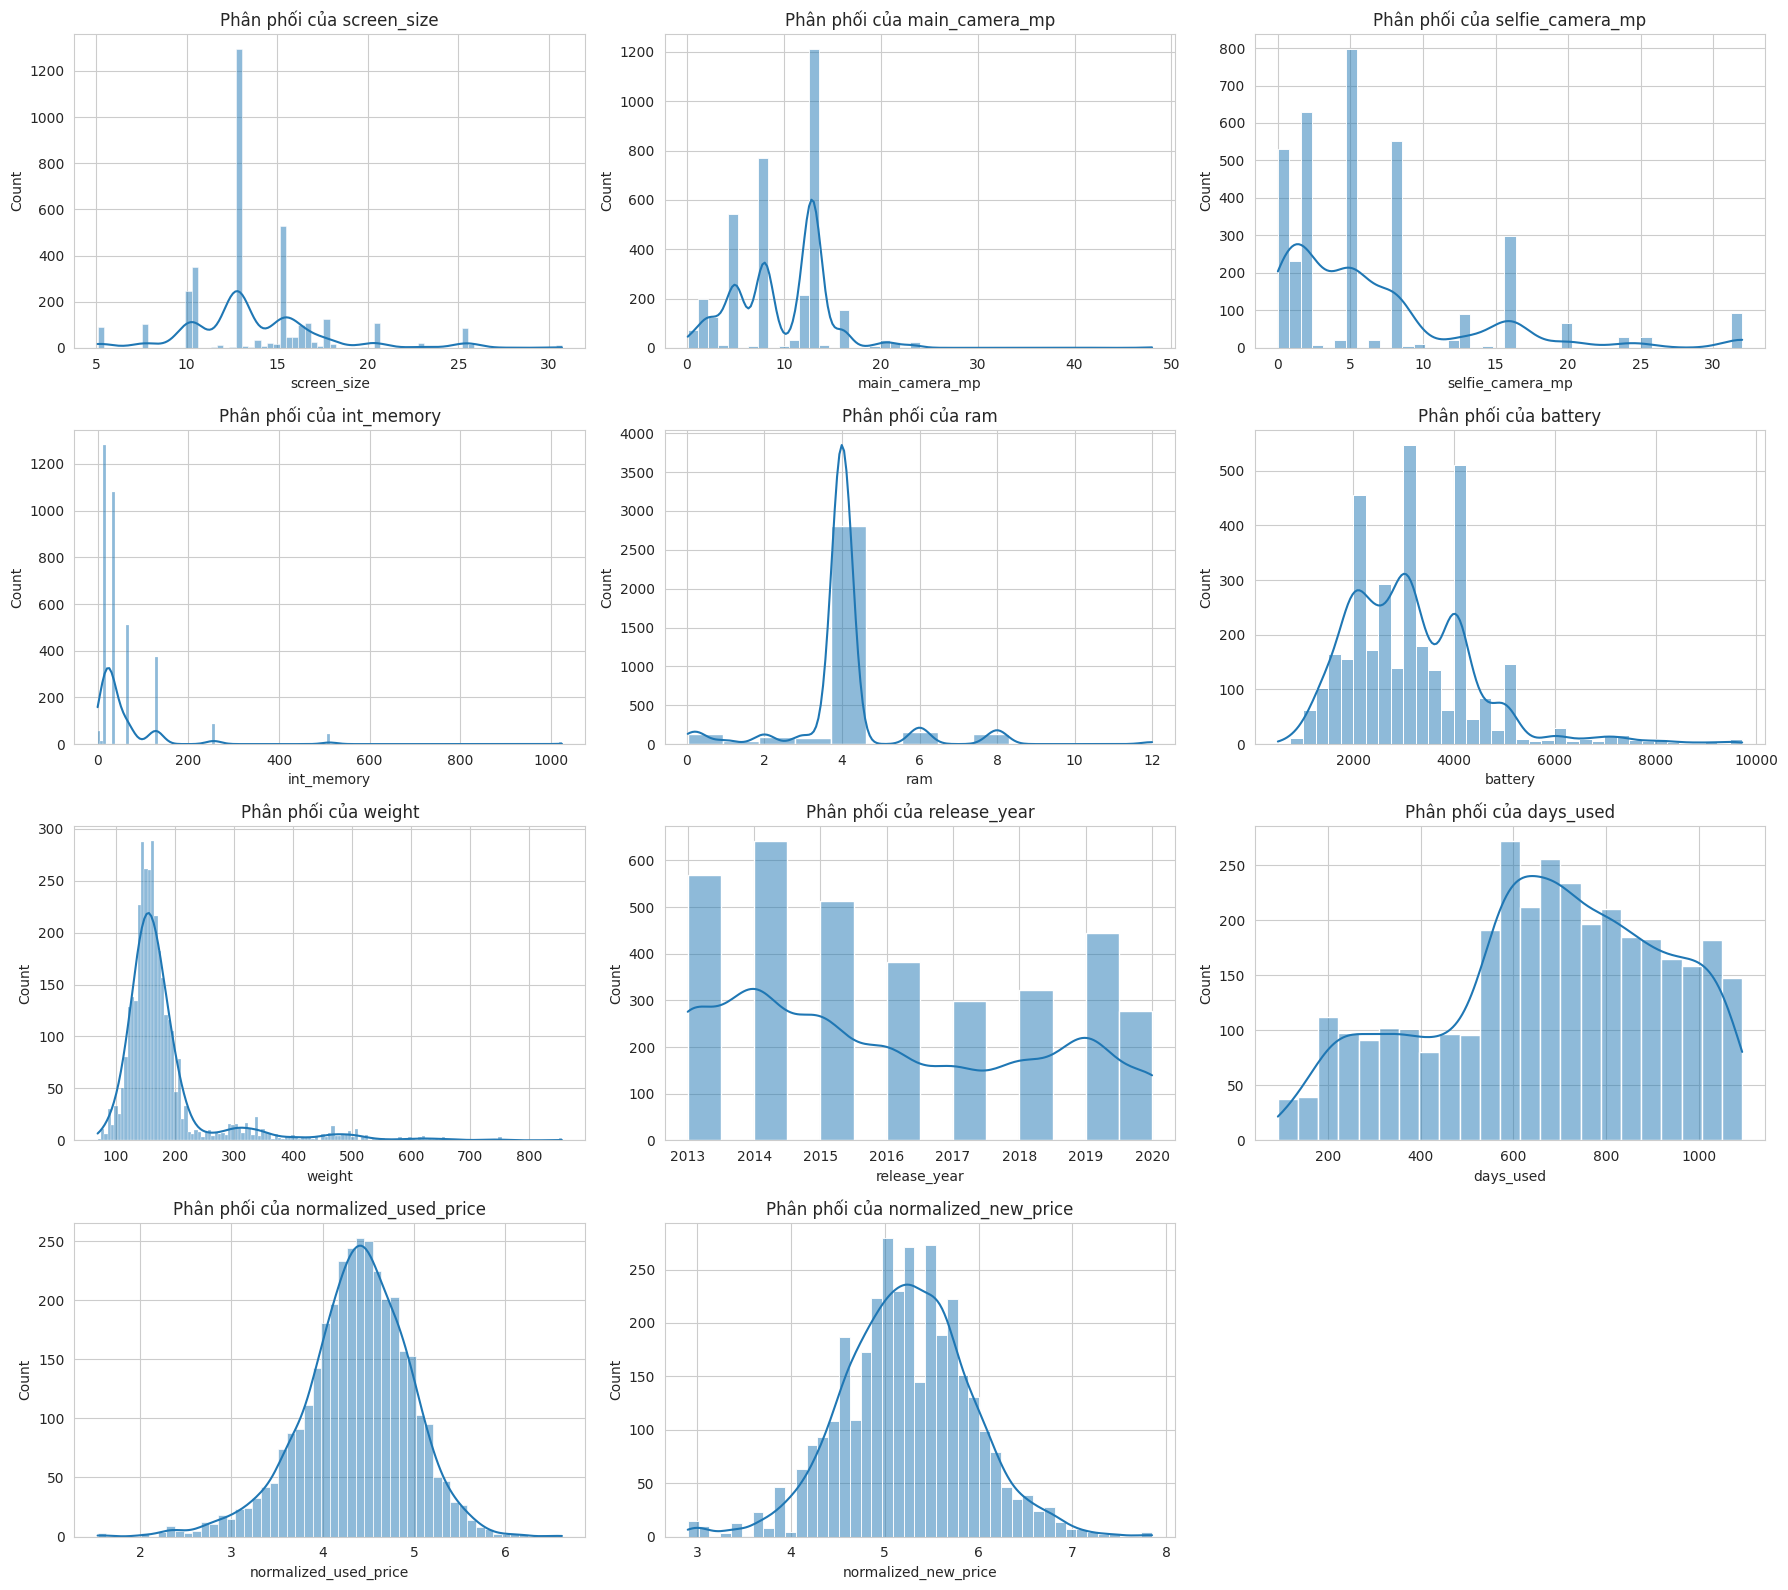

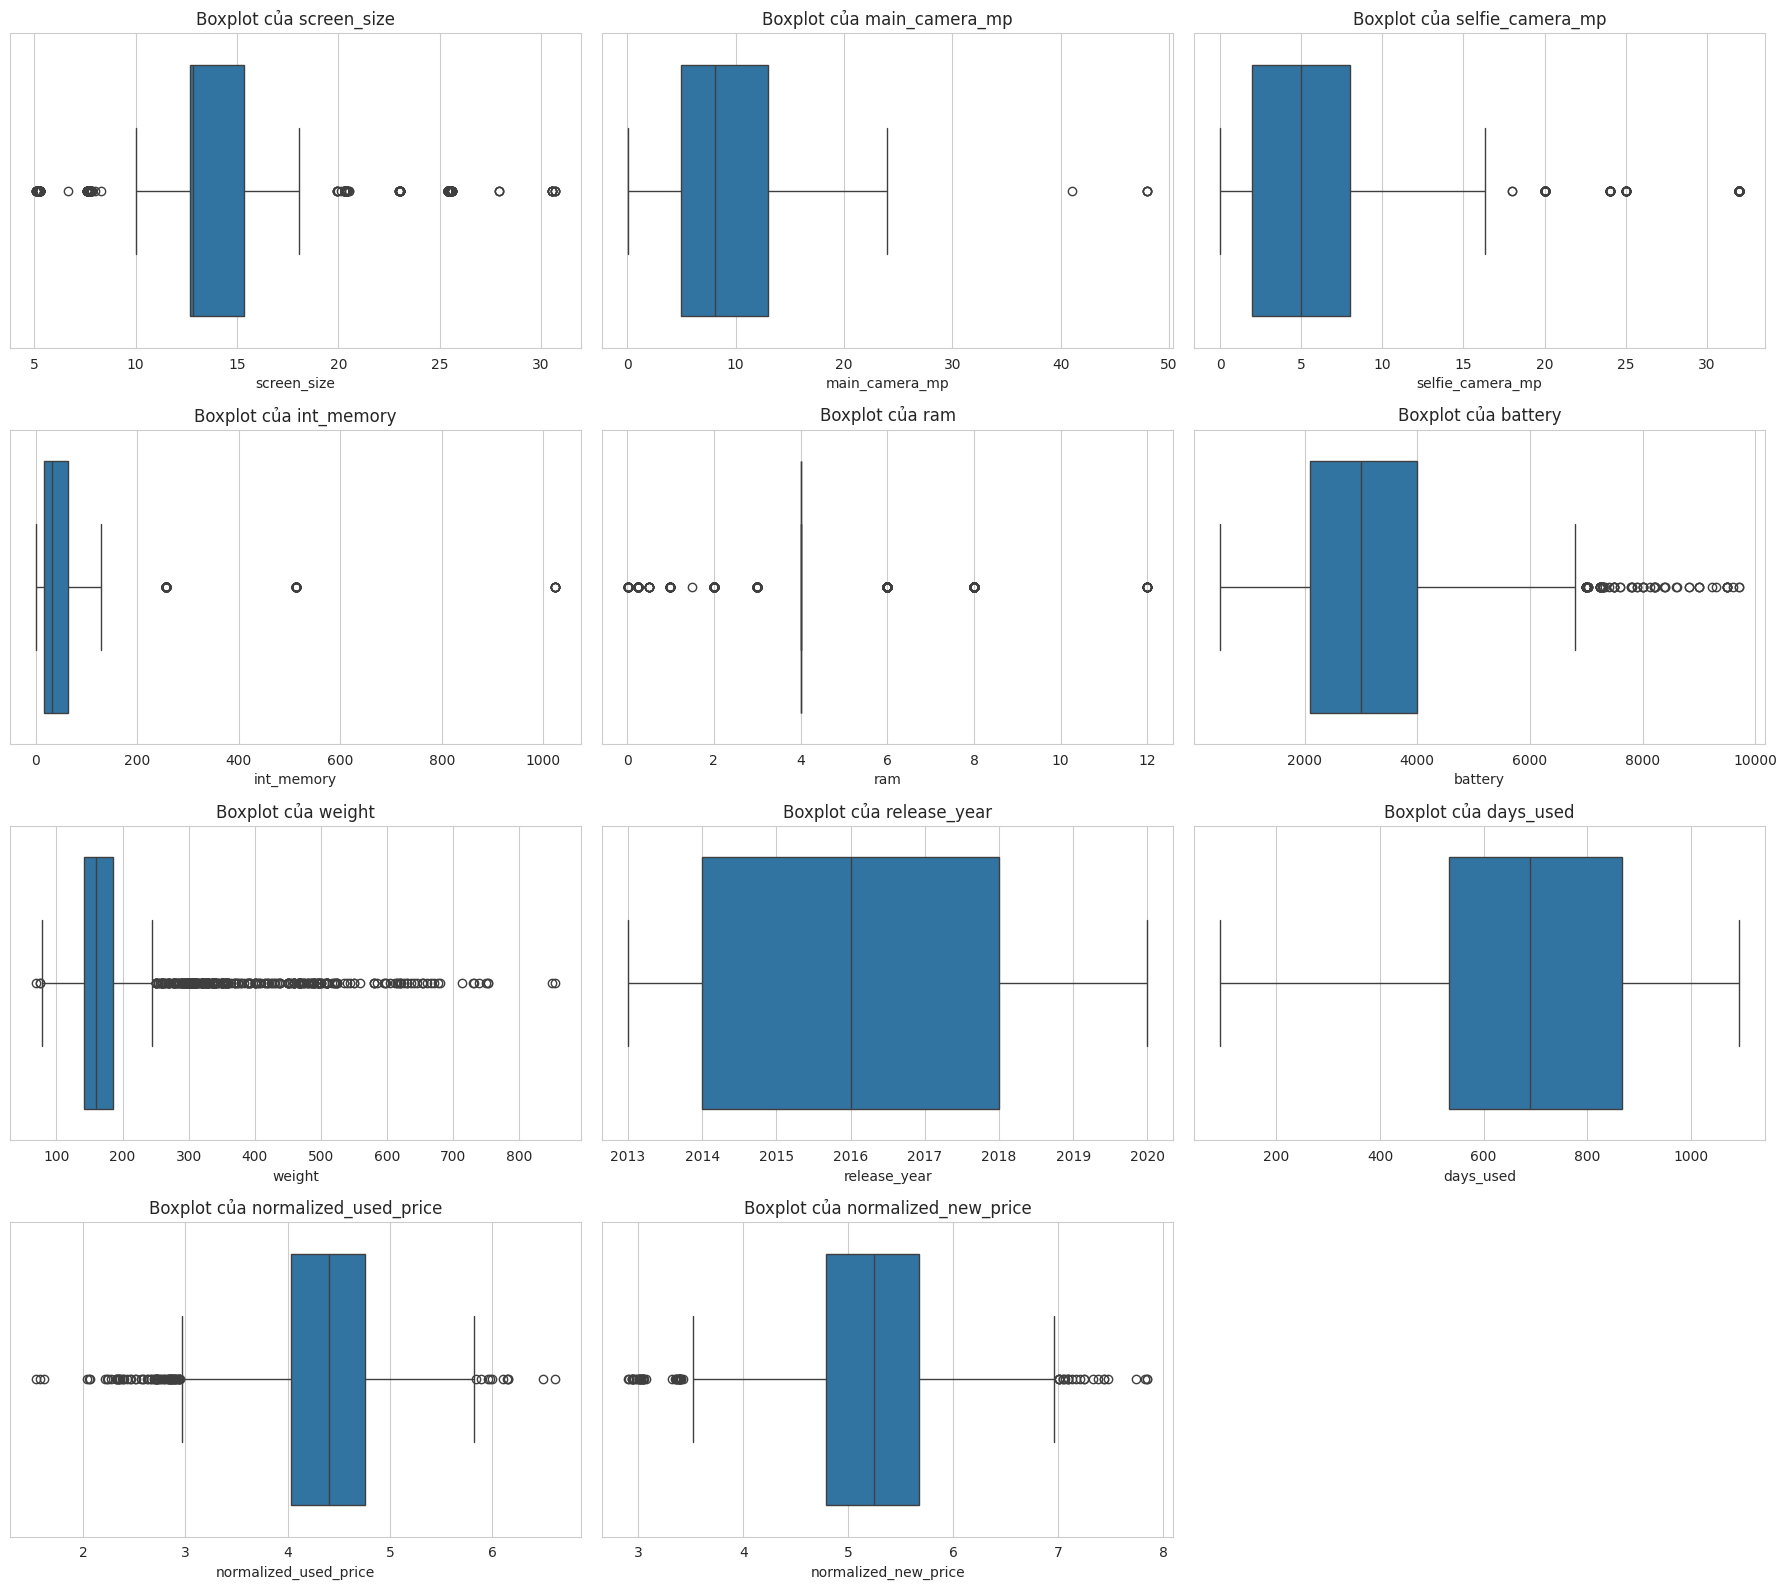

Báo cáo outlier theo phương pháp IQR:


,Thuộc tính,Số lượng outlier,Tỷ lệ (%)
4,ram,637,18.47
0,screen_size,447,12.96
6,weight,367,10.64
2,selfie_camera_mp,221,6.41
3,int_memory,138,4.00
9,normalized_used_price,84,2.44
5,battery,77,2.23
10,normalized_new_price,65,1.89
1,main_camera_mp,5,0.15
8,days_used,0,0.00


In [ ]:

# =========================================================
# 4.3. PHÂN TÍCH THỐNG KÊ VÀ TRỰC QUAN HÓA
# =========================================================
plot_numeric_distributions(df_reg)
plot_boxplots(df_reg)

print("Báo cáo outlier theo phương pháp IQR:")
display(outlier_report_iqr(df_reg))

In [ ]:
df_reg["ram"].sort_values()

,ram
116,0.02
117,0.02
2106,0.02
2102,0.02
2064,0.02
...,...
372,12.00
44,12.00
263,12.00
109,12.00


In [ ]:
df_reg[df_reg["ram"] < 0.1][["brand_name", "release_year", "ram"]]

,brand_name,release_year,ram
113,Nokia,2020,0.03
114,Nokia,2020,0.03
116,Nokia,2020,0.02
117,Nokia,2019,0.02
332,Nokia,2020,0.03
333,Nokia,2020,0.03
335,Nokia,2020,0.02
336,Nokia,2019,0.03
2044,Nokia,2018,0.02
2049,Nokia,2018,0.02


In [ ]:
df_reg.sort_values("weight", ascending=False).head(10)

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
1142,Others,Android,25.43,no,no,5.0,2.0,16.0,4.0,8380.0,855.0,2015,889,5.163585,5.480264
1141,Others,Android,30.56,no,no,8.0,2.0,32.0,4.0,2500.0,850.0,2015,652,5.239310,6.194773
2581,Samsung,Android,30.53,yes,no,8.0,2.0,32.0,4.0,9500.0,753.0,2014,1089,5.652524,6.506516
2582,Samsung,Android,30.53,no,no,8.0,2.0,32.0,4.0,9500.0,753.0,2014,1078,5.373842,6.463232
2583,Samsung,Android,30.53,no,no,8.0,2.0,32.0,4.0,9500.0,750.0,2014,689,5.274127,6.289307
2584,Samsung,Android,30.53,yes,no,8.0,2.0,32.0,4.0,9500.0,740.0,2014,921,5.336865,6.213708
2585,Samsung,Android,30.53,no,no,8.0,2.0,32.0,4.0,9500.0,732.0,2014,799,5.326856,6.150986
2586,Samsung,Android,30.53,no,no,8.0,2.0,32.0,4.0,9500.0,730.2,2014,1061,4.940499,6.042490
662,Apple,iOS,30.71,yes,no,8.0,1.2,32.0,4.0,3937.0,713.0,2015,572,5.558872,6.744671
2275,Others,Android,25.43,no,no,2.0,2.0,16.0,4.0,6400.0,680.0,2013,832,4.953712,5.437905


**Ở dataset này sẽ không cần phải xử lý outlier**

In [ ]:

# =========================================================
# 4.5. CHIA TẬP DỮ LIỆU
# =========================================================
X_reg = df_reg.drop(columns=[TARGET_COLUMN_REG, "os"]) # bỏ đi feature os vì feature brand_name sẽ tường minh hơn
y_reg = df_reg[TARGET_COLUMN_REG]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=TEST_SIZE_REG,
    random_state=RANDOM_STATE_REG,
    shuffle=True
)

print("Kích thước X_train:", X_train_reg.shape)
print("Kích thước X_test :", X_test_reg.shape)

Kích thước X_train: (2758, 13)
Kích thước X_test : (690, 13)


In [ ]:
# =========================================================
# 4.6. MÃ HÓA VÀ CHUẨN HÓA DỮ LIỆU ĐẦU VÀO
# =========================================================
# Với bài toán hồi quy:
# - Biến đầu vào dạng chữ sẽ được mã hóa bằng OneHotEncoder
# - Biến đầu vào dạng số sẽ được chuẩn hóa bằng StandardScaler
# - Biến mục tiêu y_reg giữ nguyên vì đây là bài toán dự báo giá trị số

preprocessor_reg, feature_names_reg, X_train_reg_processed, X_test_reg_processed = preview_preprocessing(
    X_train_reg, X_test_reg
)

Các cột số sẽ được chuẩn hóa:
['screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'days_used', 'normalized_new_price']

Các cột phân loại sẽ được mã hóa One-Hot:
['brand_name', '4g', '5g']

Kích thước dữ liệu trước tiền xử lý:
X_train gốc: (2758, 13)
X_test gốc : (690, 13)

Kích thước dữ liệu sau tiền xử lý:
X_train sau mã hóa + chuẩn hóa: (2758, 45)
X_test sau mã hóa + chuẩn hóa : (690, 45)

Xem trước 5 dòng đầu sau khi mã hóa và chuẩn hóa:


,num__screen_size,num__main_camera_mp,num__selfie_camera_mp,num__int_memory,num__ram,num__battery,num__weight,num__release_year,num__days_used,num__normalized_new_price,...,cat__brand_name_Realme,cat__brand_name_Samsung,cat__brand_name_Sony,cat__brand_name_Spice,cat__brand_name_Vivo,cat__brand_name_XOLO,cat__brand_name_Xiaomi,cat__brand_name_ZTE,cat__4g_yes,cat__5g_yes
0,0.810395,0.702901,1.383964,0.830887,-0.021409,0.674615,-0.205158,1.324083,-1.213222,0.029297,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.220770,0.702901,-0.647662,-0.260281,-0.021409,-0.097642,-0.365059,-0.865521,0.945645,0.689215,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.441180,0.702901,0.214683,-0.260281,-0.758735,0.674615,0.094947,1.762004,-2.327084,-0.137922,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.255054,0.702901,-0.223798,-0.442142,-0.021409,-0.560996,-0.454280,0.448242,-0.083158,-0.779470,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.220770,0.702901,1.383964,0.103442,-0.021409,-0.097642,-0.199364,0.448242,0.824133,-0.659278,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


In [ ]:
print(feature_names_reg)

['num__screen_size' 'num__main_camera_mp' 'num__selfie_camera_mp'
 'num__int_memory' 'num__ram' 'num__battery' 'num__weight'
 'num__release_year' 'num__days_used' 'num__normalized_new_price'
 'cat__brand_name_Alcatel' 'cat__brand_name_Apple' 'cat__brand_name_Asus'
 'cat__brand_name_BlackBerry' 'cat__brand_name_Celkon'
 'cat__brand_name_Coolpad' 'cat__brand_name_Gionee'
 'cat__brand_name_Google' 'cat__brand_name_HTC' 'cat__brand_name_Honor'
 'cat__brand_name_Huawei' 'cat__brand_name_Infinix'
 'cat__brand_name_Karbonn' 'cat__brand_name_LG' 'cat__brand_name_Lava'
 'cat__brand_name_Lenovo' 'cat__brand_name_Meizu'
 'cat__brand_name_Micromax' 'cat__brand_name_Microsoft'
 'cat__brand_name_Motorola' 'cat__brand_name_Nokia'
 'cat__brand_name_OnePlus' 'cat__brand_name_Oppo' 'cat__brand_name_Others'
 'cat__brand_name_Panasonic' 'cat__brand_name_Realme'
 'cat__brand_name_Samsung' 'cat__brand_name_Sony' 'cat__brand_name_Spice'
 'cat__brand_name_Vivo' 'cat__brand_name_XOLO' 'cat__brand_name_Xiaomi'


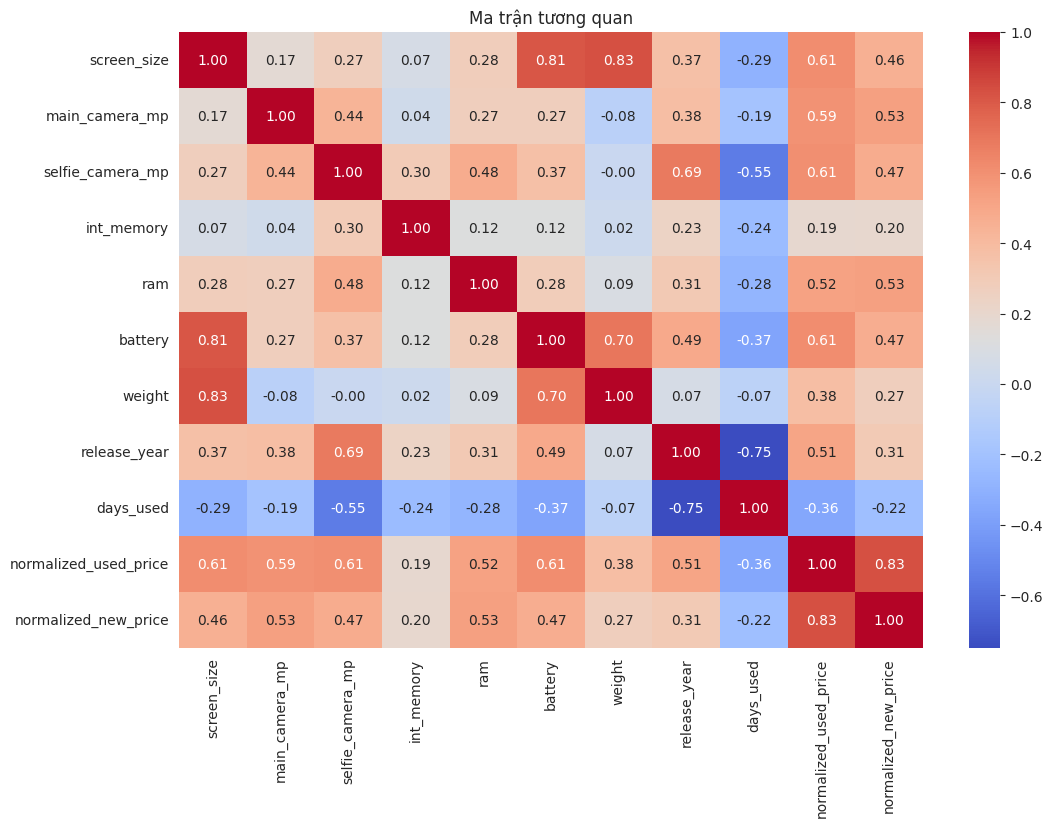

In [ ]:

# =========================================================
# 4.7. MA TRẬN TƯƠNG QUAN VÀ CHỌN ĐẶC TRƯNG TỰ ĐỘNG
# =========================================================
plot_correlation_matrix(df_reg, TARGET_COLUMN_REG)



#Trong ma trận tương quna ta thấy được ba feature có đa cộng tuyến với nhau là:
# - screen_size, weight và battery

- Giá đt cũ thường bị ảnh hưởng bởi: screen_size, main_camera_mp, selfie_camera_mp, ram, battery, release_year, normalized_new_price và day_use


- Thử chọn đặc trưng bằng các tính chỉ số VIF

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X_processed, feature_names):

    # Chuyển sparse -> ndarray
    if hasattr(X_processed, "toarray"):
        X_processed = X_processed.toarray()

    X = pd.DataFrame(
        X_processed,
        columns=feature_names
    )

    vif = pd.DataFrame({
        "Feature": X.columns,
        "VIF": [
            variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])
        ]
    })

    return vif.sort_values("VIF", ascending=False)

In [ ]:
vif_table = calculate_vif(
    X_train_reg_processed,
    feature_names_reg
)

display(vif_table.head(30))

,Feature,VIF
43,cat__4g_yes,7.374586
0,num__screen_size,6.407823
6,num__weight,5.606609
7,num__release_year,4.708746
5,num__battery,4.158436
9,num__normalized_new_price,3.072716
2,num__selfie_camera_mp,2.807488
8,num__days_used,2.516817
1,num__main_camera_mp,2.306287
4,num__ram,2.191067


In [ ]:

# =========================================================
# 4.7. CHỌN ĐẶC TRƯNG TỰ ĐỘNG
# =========================================================
selected_names_reg, selected_table_reg = get_selected_feature_names(
    X_train_reg, y_train_reg,
    problem_type="regression",
    k=K_BEST_REG
)

print("Các đặc trưng được chọn tự động:")
for name in selected_names_reg:
    print("-", name)

display(selected_table_reg.head(30))

Các đặc trưng được chọn tự động:
- num__screen_size
- num__main_camera_mp
- num__selfie_camera_mp
- num__ram
- num__battery
- num__weight
- num__release_year
- num__days_used
- num__normalized_new_price
- cat__4g_yes


,Đặc trưng,Score,P-value,Được chọn
9,num__normalized_new_price,6428.921313,0.000000e+00,True
5,num__battery,1726.730368,1.852245e-293,True
0,num__screen_size,1718.696422,2.197042e-292,True
2,num__selfie_camera_mp,1621.119320,3.502200e-279,True
1,num__main_camera_mp,1509.319677,1.092771e-263,True
43,cat__4g_yes,1191.417087,2.672643e-217,True
4,num__ram,1089.245412,1.363516e-201,True
7,num__release_year,993.034765,2.058411e-186,True
6,num__weight,504.052623,1.168211e-102,True
8,num__days_used,387.822271,6.961658e-81,True


# **Nhược điểm của SelectKBest là nó không xét đến cộng tuyến của các feature, nó tính score từ feature đến target và chọn nó**

In [ ]:
# =========================================================
# 4.8. HUẤN LUYỆN 3 MÔ HÌNH HỒI QUY
# =========================================================

models_reg = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_STATE_REG),
    "XGBoost": XGBRegressor(random_state=RANDOM_STATE_REG)
}

results_reg = []
trained_pipes = {}

for model_name, model in models_reg.items():

    pipe = build_model_pipeline(
        X_train_reg,
        model,
        problem_type="regression",
        k=K_BEST_REG
    )

    # =====================================================
    # GridSearchCV cho Random Forest và XGBoost
    # =====================================================
    if model_name in ["Random Forest", "XGBoost"]:

        if model_name == "Random Forest":
            param_grid = {
                "model__n_estimators": [100, 200],
                "model__max_depth": [10, 20, None],
                "model__min_samples_split": [2, 5],
                "model__max_features": ["sqrt", "log2"]
            }

        elif model_name == "XGBoost":
            param_grid = {
                "model__n_estimators": [300, 500],
                "model__learning_rate": [0.03, 0.05],
                "model__max_depth": [4, 6],
                "model__subsample": [0.8],
                "model__colsample_bytree": [0.8],
                "model__min_child_weight": [1, 3]
            }

        grid_search = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring="r2",
            cv=5,
            n_jobs=-1,
            verbose=2
        )

        grid_search.fit(X_train_reg, y_train_reg)

        print(f"\n========== {model_name} ==========")
        print("Best Parameters:", grid_search.best_params_)
        print("Best CV R2:", round(grid_search.best_score_, 4))

        pipe = grid_search.best_estimator_

    else:
        pipe.fit(X_train_reg, y_train_reg)

    # =====================================================
    # Đánh giá trên tập Test
    # =====================================================
    y_pred_reg = pipe.predict(X_test_reg)

    trained_pipes[model_name] = pipe

    mae = mean_absolute_error(y_test_reg, y_pred_reg)
    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred_reg)

    results_reg.append({
        "Mô hình": model_name,
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

# =========================================================
# Kết quả
# =========================================================
results_reg_df = (
    pd.DataFrame(results_reg)
    .sort_values(by="R2", ascending=False)
    .reset_index(drop=True)
)

display(results_reg_df)

Fitting 5 folds for each of 24 candidates, totalling 120 fits

========== Random Forest ==========
Best Parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV R2: 0.8486
Fitting 5 folds for each of 16 candidates, totalling 80 fits

========== XGBoost ==========
Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV R2: 0.8528


,Mô hình,MAE,MSE,RMSE,R2
0,XGBoost,0.1794,0.0511,0.2260,0.8495
1,Random Forest,0.1833,0.0540,0.2323,0.8409
2,Linear Regression,0.1886,0.0574,0.2396,0.8309


In [ ]:
# Lấy tên mô hình có R2 cao nhất
best_reg_model_name = results_reg_df.iloc[0]["Mô hình"]

# Lấy object model tương ứng
best_reg_model = models_reg[best_reg_model_name]

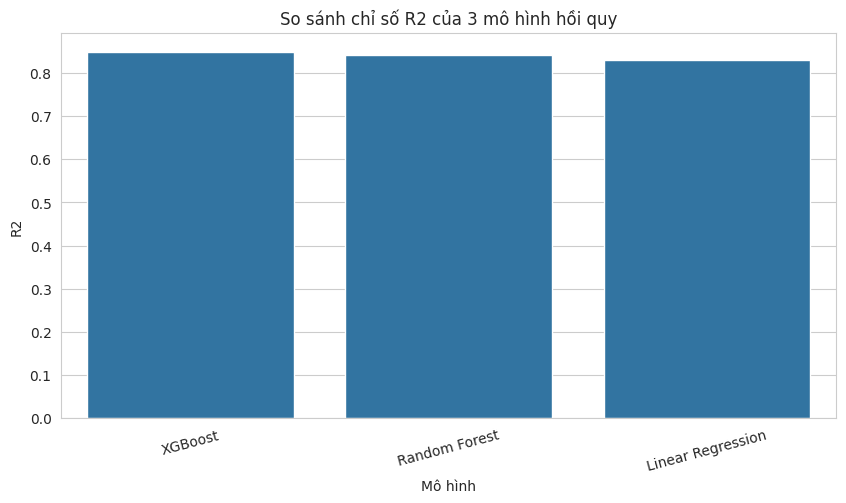

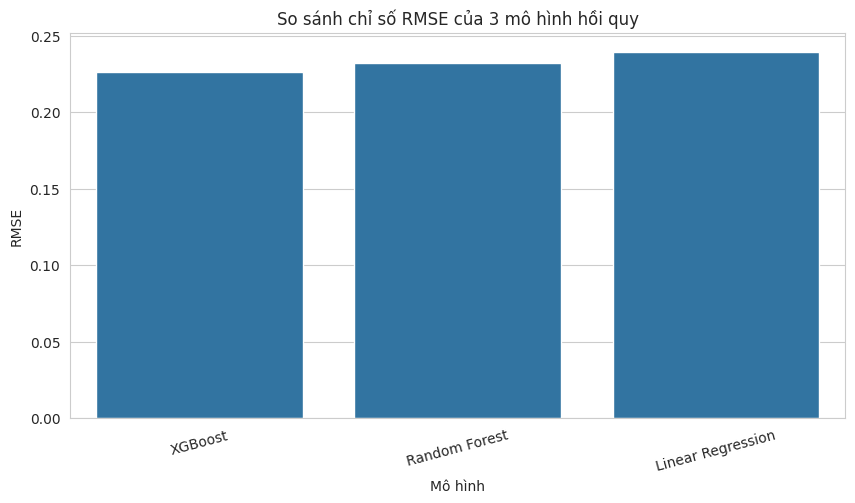

In [ ]:

# =========================================================
# 4.9. VẼ BIỂU ĐỒ SO SÁNH KẾT QUẢ 3 MÔ HÌNH HỒI QUY
# =========================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=results_reg_df, x="Mô hình", y="R2")
plt.title("So sánh chỉ số R2 của 3 mô hình hồi quy")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=results_reg_df, x="Mô hình", y="RMSE")
plt.title("So sánh chỉ số RMSE của 3 mô hình hồi quy")
plt.xticks(rotation=15)
plt.show()

In [ ]:

# =========================================================
# 4.10. DỰ ĐOÁN THỬ BẰNG MÔ HÌNH TỐT NHẤT
# =========================================================
if best_reg_model_name == "XGBoost":
    best_reg_pipe = trained_pipes["XGBoost"]
else:
    best_reg_pipe = build_model_pipeline(
        X_train_reg,
        best_reg_model,
        problem_type="regression",
        k=K_BEST_REG
    )

    best_reg_pipe.fit(X_train_reg, y_train_reg)
y_pred_best_reg = best_reg_pipe.predict(X_test_reg)

result_compare_reg = pd.DataFrame({
    "Giá trị thực": y_test_reg.values[:20],
    "Giá trị dự đoán": y_pred_best_reg[:20]
})

print("Mô hình tốt nhất cho bài toán hồi quy:", best_reg_model_name)
display(result_compare_reg)

Mô hình tốt nhất cho bài toán hồi quy: XGBoost


,Giá trị thực,Giá trị dự đoán
0,4.890875,4.920328
1,5.001191,4.865415
2,3.756538,3.805168
3,4.937132,4.669043
4,4.711780,4.542190
5,3.341447,3.340511
6,4.476200,4.317543
7,5.412048,5.200013
8,3.971989,4.005930
9,5.152598,4.860847


In [ ]:
#test dữ liệu bên ngoài

new_data = pd.DataFrame({
    "brand_name": ["Samsung"],
    "screen_size": [13],
    "main_camera_mp": [20],
    "selfie_camera_mp": [7],
    "ram": [16],
    "int_memory": [256],
    "battery": [5000.0],
    "weight": [146],
    "release_year": [2024],
    "days_used": [365],
    "normalized_new_price": [7.805334],
    "4g": ["yes"],
    "5g": ["yes"]
})

In [ ]:
best_pipe = trained_pipes["Linear Regression"]
prediction = best_pipe.predict(new_data)
print("Giá dự đoán:", prediction[0])

Giá dự đoán: 6.125371184414575


In [ ]:
df_reg["normalized_used_price"].sort_values()

,normalized_used_price
885,1.536867
323,1.572774
533,1.617406
2320,2.033398
2533,2.052841
...,...
2135,6.143348
34,6.153456
645,6.158969
3207,6.500448
